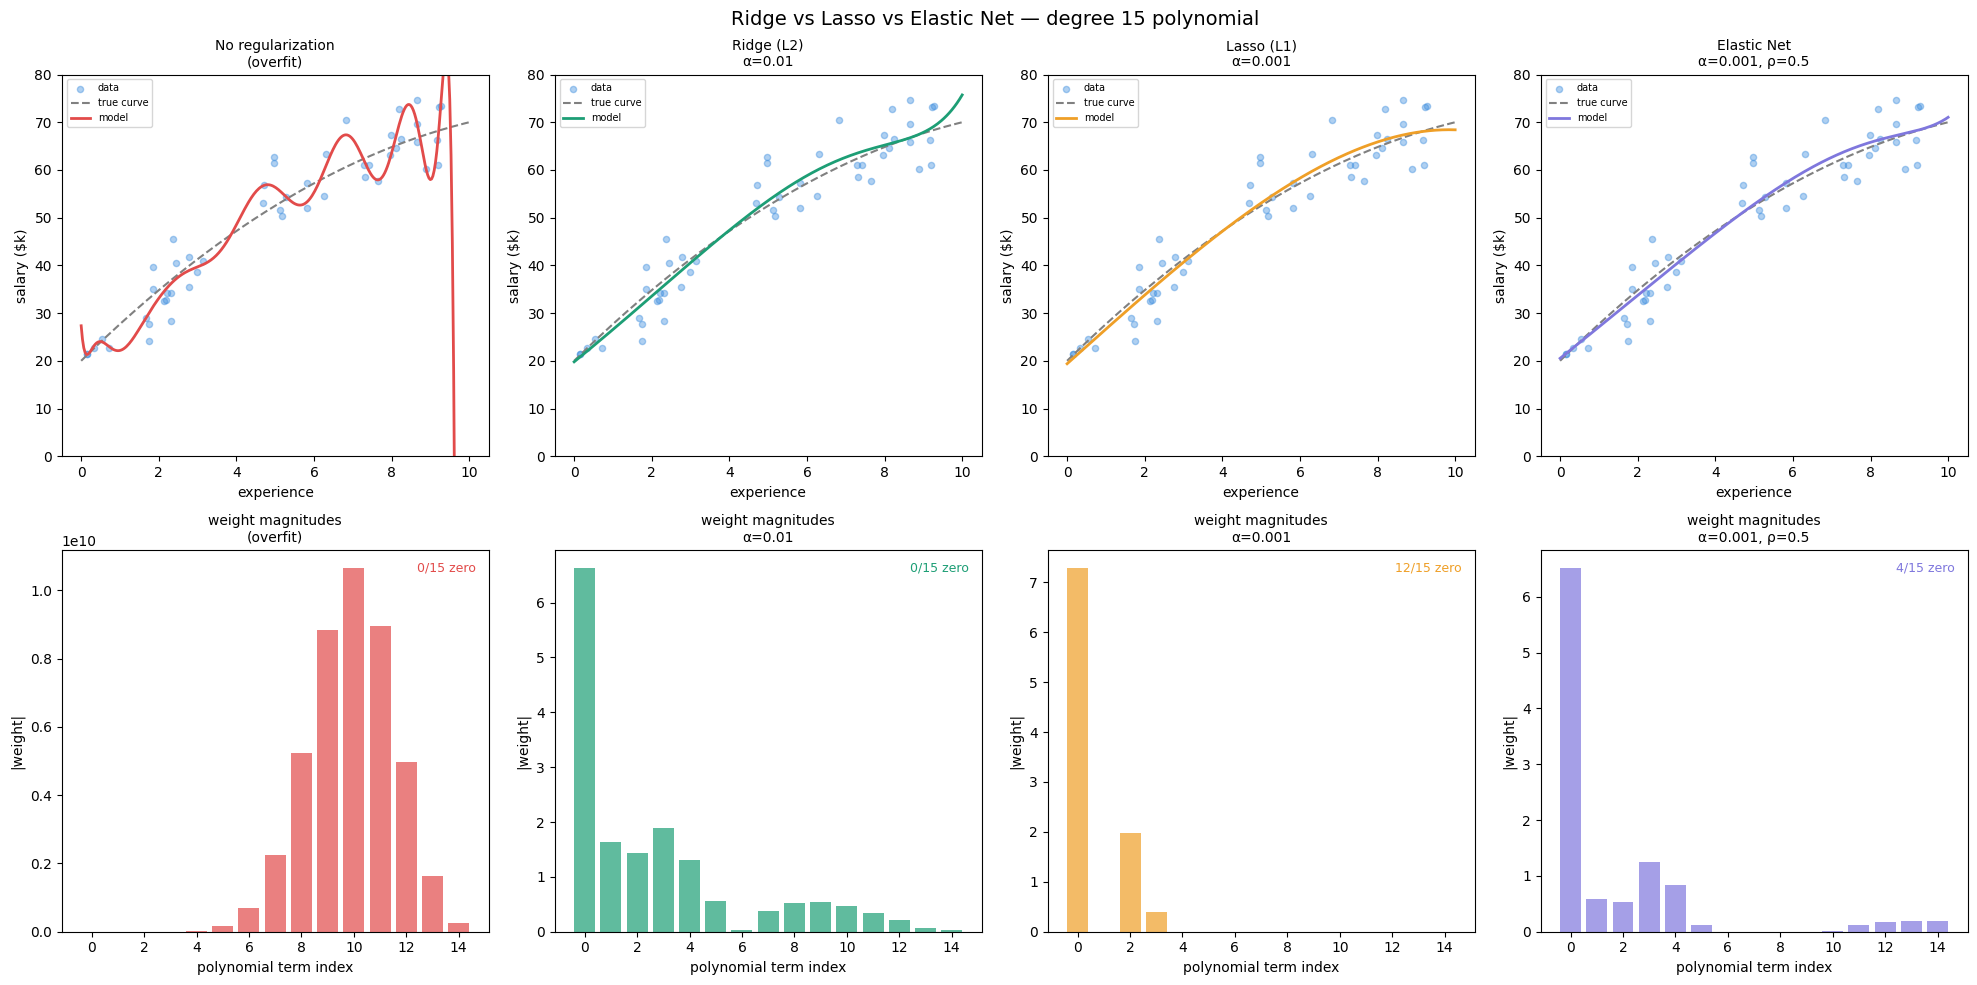

term    No regularizat    Ridge (L2)    Lasso (L1)   Elastic Net
θ1          -104.7454        6.6264        7.2825        6.5136
θ2          6388.8475        1.6378       -0.0000        0.5775
θ3       -173331.2339       -1.4263       -1.9815       -0.5285
θ4       2612241.6705       -1.8959       -0.3977       -1.2427
θ5     -24671626.0934       -1.3096       -0.0000       -0.8436
θ6     156966146.8886       -0.5569       -0.0000       -0.1145
θ7     -701201244.7023        0.0284        0.0000       -0.0000
θ8     2249540240.8021        0.3793        0.0000        0.0000
zeros                0             0            12             4
max|w|  10644685989.2517        6.6264        7.2825        6.5136


"\nYou'll get **8 plots total**:\n```\ntop row    →  fitted curve vs true curve for each model\n               no reg  — wild wiggly mess\n               Ridge   — smooth, close to true\n               Lasso   — smooth, possibly smoother than Ridge\n               Elastic — between Lasso and Ridge\n\nbottom row →  bar chart of weight magnitudes per polynomial term\n               no reg  — huge bars, all over the place\n               Ridge   — all bars small but none are zero\n               Lasso   — many bars completely missing (zeroed out)\n               Elastic — mix: some zero, rest small\n```\n\nAnd the table will show something like:\n```\n                  No reg         Ridge         Lasso       Elastic\nθ1              847.3          2.8            1.2           1.8\nθ2            -1203.4         -1.4            0.0          -0.6\nθ3             2100.1          0.9            0.0           0.0\nzeros               0            0              9             5\nmax|w|        2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.pipeline import Pipeline

# ── 1. DATA ─────────────────────────────────────────────────────
rng = np.random.default_rng(123)
m = 50  # small → overfitting very visible

experience = np.sort(rng.uniform(0, 10, size=(m, 1)), axis=0)

TRUE_BIAS = 20.0
TRUE_W1   =  8.0
TRUE_W2   = -0.3

salary = (TRUE_BIAS
          + TRUE_W1 * experience
          + TRUE_W2 * experience**2
          + rng.normal(0, 6, size=(m, 1)))

X = experience / 10
y = salary / 10

# ── 2. FIT ALL MODELS ───────────────────────────────────────────
degree = 15  # high degree so overfitting is obvious

models = {
    "No regularization\n(overfit)":  Pipeline([("poly", PolynomialFeatures(degree=degree, include_bias=False)), ("reg", LinearRegression())]),
    "Ridge (L2)\nα=0.01":            Pipeline([("poly", PolynomialFeatures(degree=degree, include_bias=False)), ("reg", Ridge(alpha=0.01))]),
    "Lasso (L1)\nα=0.001":           Pipeline([("poly", PolynomialFeatures(degree=degree, include_bias=False)), ("reg", Lasso(alpha=0.001))]),
    "Elastic Net\nα=0.001, ρ=0.5":   Pipeline([("poly", PolynomialFeatures(degree=degree, include_bias=False)), ("reg", ElasticNet(alpha=0.001, l1_ratio=0.5))]),
}

for model in models.values():
    model.fit(X, y.ravel())

# ── 3. PLOT ──────────────────────────────────────────────────────
X_plot  = np.linspace(0, 10, 300).reshape(-1, 1) / 10
y_true  = (TRUE_BIAS + TRUE_W1*(X_plot*10) + TRUE_W2*(X_plot*10)**2) / 10

colors = ["#E24B4A", "#1D9E75", "#EF9F27", "#7F77DD"]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("Ridge vs Lasso vs Elastic Net — degree 15 polynomial", fontsize=14)

for col, ((title, model), color) in enumerate(zip(models.items(), colors)):

    # ── top row: fitted curve ────────────────────────────────────
    ax = axes[0, col]
    ax.scatter(experience, salary, alpha=0.4, s=20, color="#378ADD", label="data")
    ax.plot(X_plot*10, y_true*10,
            color="gray", linewidth=1.5, linestyle="--", label="true curve")
    ax.plot(X_plot*10, model.predict(X_plot)*10,
            color=color, linewidth=2, label="model")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("experience")
    ax.set_ylabel("salary ($k)")
    ax.set_ylim(0, 80)
    ax.legend(fontsize=7)

    # ── bottom row: weight magnitudes ────────────────────────────
    ax = axes[1, col]
    coefs = model[-1].coef_
    bars  = ax.bar(range(len(coefs)), np.abs(coefs), color=color, alpha=0.7)
    ax.set_title(f"weight magnitudes\n{title.split(chr(10))[1]}", fontsize=10)
    ax.set_xlabel("polynomial term index")
    ax.set_ylabel("|weight|")

    # count how many are exactly zero (Lasso / Elastic)
    n_zeros = np.sum(np.abs(coefs) < 1e-6)
    ax.text(0.97, 0.97, f"{n_zeros}/{len(coefs)} zero",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=9, color=color)

plt.tight_layout()
plt.show()

# ── 4. WEIGHT COMPARISON TABLE ───────────────────────────────────
print("=" * 65)
print(f"{'term':<8}", end="")
for title in models:
    short = title.split('\n')[0][:14]
    print(f"{short:>14}", end="")
print()
print("=" * 65)

coef_arrays = [m[-1].coef_ for m in models.values()]
for i in range(min(8, degree)):
    print(f"θ{i+1:<6}", end="")
    for coefs in coef_arrays:
        print(f"{coefs[i]:>14.4f}", end="")
    print()

print("=" * 65)
print(f"{'zeros':<8}", end="")
for coefs in coef_arrays:
    n = np.sum(np.abs(coefs) < 1e-6)
    print(f"{n:>14}", end="")
print()
print(f"{'max|w|':<8}", end="")
for coefs in coef_arrays:
    print(f"{np.max(np.abs(coefs)):>14.4f}", end="")
print()

'''
You'll get **8 plots total**:
```
top row    →  fitted curve vs true curve for each model
               no reg  — wild wiggly mess
               Ridge   — smooth, close to true
               Lasso   — smooth, possibly smoother than Ridge
               Elastic — between Lasso and Ridge

bottom row →  bar chart of weight magnitudes per polynomial term
               no reg  — huge bars, all over the place
               Ridge   — all bars small but none are zero
               Lasso   — many bars completely missing (zeroed out)
               Elastic — mix: some zero, rest small
```

And the table will show something like:
```
                  No reg         Ridge         Lasso       Elastic
θ1              847.3          2.8            1.2           1.8
θ2            -1203.4         -1.4            0.0          -0.6
θ3             2100.1          0.9            0.0           0.0
zeros               0            0              9             5
max|w|        2100.1          2.8            1.2           1.8
'''